In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import datetime as d
#get our dataset 
import tooling
dfc = tooling.get_data()
dfc.columns

Index(['date', 'price', 'house_id', 'id', 'bedrooms', 'bathrooms',
       'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition',
       'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15',
       'renovation_status', 'area_quality', 'price_per_sqft', 'weekday',
       'month'],
      dtype='object')

<Figure size 1000x600 with 0 Axes>

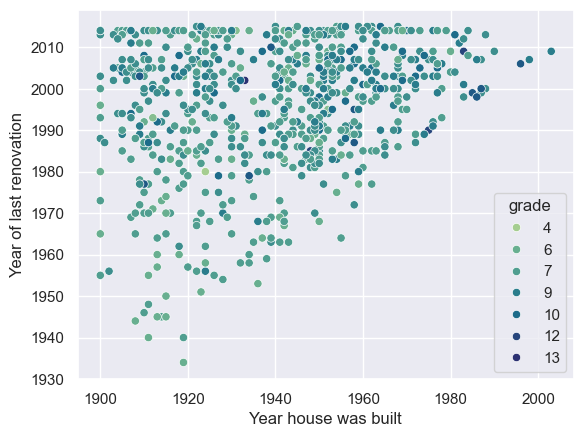

<Figure size 1000x600 with 0 Axes>

In [40]:
dfc.columns=dfc.columns.str.replace('yr', 'year')
dfc.columns
dfcx = dfc.query('year_renovated != 0')
sns.set_theme(style='darkgrid')
sns.scatterplot(data=dfcx, x='year_built', y='year_renovated', hue='grade', palette='crest')
plt.xlabel('Year house was built')
plt.ylabel('Year of last renovation')
plt.figure(figsize=(10,6))


<Axes: xlabel='renovation_status', ylabel='condition'>

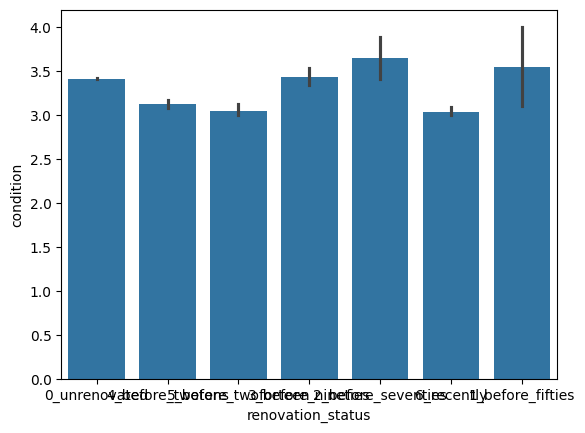

In [38]:
sns.barplot(data = dfc, x='renovation_status', y='condition')


In [22]:
dfct = dfc.query('month == "November"')
dfct.describe()

,date,price,house_id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price_per_sqft
count,1396,1.396000e+03,1.396000e+03,1396.000000,1396.000000,1396.000000,1396.000000,1396.000000,1396.000000,1396.0,...,1396.000000,1364.000000,1396.000000,1396.0,1396.000000,1396.000000,1396.000000,1396.000000,1396.000000,1396.000000
mean,2014-11-14 04:07:33.868194816,5.238413e+05,4.518910e+09,10823.505014,3.333811,2.083632,2053.727077,15289.633954,1.505014,0.209169,...,1781.553009,273.493402,1970.208453,67.108166,98078.549427,47.557815,-122.218650,1944.272923,12941.648281,258.305874
min,2014-11-01 00:00:00,9.000000e+04,6.200017e+06,25.000000,1.000000,0.750000,460.000000,745.000000,1.000000,0.0,...,460.000000,0.000000,1900.000000,0.0,98001.000000,47.179500,-122.514000,620.000000,660.000000,91.000000
25%,2014-11-07 00:00:00,3.100000e+05,2.173878e+09,5203.750000,3.000000,1.500000,1400.000000,5001.000000,1.000000,0.0,...,1190.000000,0.000000,1950.000000,0.0,98032.750000,47.465725,-122.329000,1440.000000,5000.000000,178.000000
50%,2014-11-14 00:00:00,4.350000e+05,3.876307e+09,11052.000000,3.000000,2.000000,1870.000000,7484.500000,1.500000,0.0,...,1565.000000,0.000000,1973.500000,0.0,98072.000000,47.573800,-122.235000,1805.000000,7500.000000,238.000000
75%,2014-11-20 00:00:00,6.166125e+05,7.227576e+09,16329.750000,4.000000,2.500000,2550.000000,10452.000000,2.000000,0.0,...,2220.000000,500.000000,1996.000000,0.0,98118.000000,47.676050,-122.134000,2272.500000,9889.500000,308.000000
max,2014-11-30 00:00:00,3.850000e+06,9.834200e+09,21573.000000,8.000000,5.250000,7620.000000,577605.000000,3.000000,2.0,...,6110.000000,2610.000000,2015.000000,2014.0,98199.000000,47.776400,-121.352000,4800.000000,560617.000000,781.000000
std,NaN,3.566961e+05,2.814113e+09,6311.675511,0.902583,0.755054,917.580150,41294.219062,0.536793,0.604003,...,830.446252,427.308695,29.659965,359.666304,53.527868,0.141547,0.138656,677.671242,29902.131882,106.617382


In [15]:
dfct = tooling.get_timedata()
dfct.columns

AttributeError: module 'tooling' has no attribute 'get_timedata'

In [ ]:
def print_weekday(date):
    return date.strftime('%a')
def print_month(date):
    return date.strftime('%B')
dfc['weekday'] = dfc['date']
dfc['weekday'] = dfc['weekday'].apply(print_weekday)
dfc['month'] = dfc['date']
dfc['month'] = dfc['month'].apply(print_month)
dfc['price_per_sqft'] = dfc['price_per_sqft'].astype(int)

dfct = dfc[['date', 'price', 'grade', 'price_per_sqft', 'condition', 'house_id', 'month', 'weekday']]
dfct.head()

,date,price,grade,price_per_sqft,condition,house_id,month,weekday
0,2014-10-13,221900.0,7,188,3,7129300520,October,Mon
1,2014-12-09,538000.0,7,209,3,6414100192,December,Tue
2,2015-02-25,180000.0,6,233,3,5631500400,February,Wed
3,2014-12-09,604000.0,7,308,5,2487200875,December,Tue
4,2015-02-18,510000.0,8,303,3,1954400510,February,Wed


In [18]:
counts = dfct.groupby(["month"]).sum()
counts.head()

TypeError: datetime64 type does not support sum operations

In [ ]:
dfcx= dfc.copy()
dfcx['yr_renovated'] = dfcx['yr_renovated'].astype(str)

#Remove the trailing '0' ONLY if the value is not '0'.
#We use a lambda function to only target the large numbers.
def fix_year_format(year_str):
    if year_str != '0' and len(year_str) == 7:
        return year_str[:-3]  # Remove the last character (the extra '0')
    return year_str

dfcx['yr_renovated'] = dfcx['yr_renovated'].apply(fix_year_format)
dfcx['yr_renovated'] = pd.to_numeric(
    dfcx['yr_renovated'],
    errors='coerce'
)
dfcx['yr_renovated'] = dfcx['yr_renovated'].astype('Int64')
dfcx['yr_renovated'] = dfcx['yr_renovated'].fillna(0)
test = dfcx.query('yr_renovated != 0' )
test['yr_renovated']